# Day 10: Simple RNN for Text Classification (Sarcasm Detection)

## 1. Load the Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day10/Sarcasm_Headlines_Dataset_v2_backup.json"
data = pd.read_json(url, lines=True)

print(data.head())

   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huffingtonpost.com/entry/eat-your-...  
3  https://local.theonion.com/inclement-weather-p...  
4  https://www.theonion.com/mother-comes-pretty-c...  


## 2. Exploratory Data Analysis (EDA)


Data Shape: (28619, 3)

Missing Values:
 is_sarcastic    0
headline        0
article_link    0
dtype: int64


/tmp/ipykernel_1504/1620707770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['is_sarcastic'], palette='viridis')


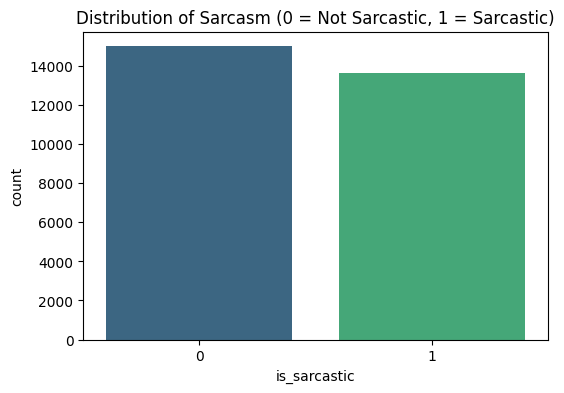

In [2]:
print("Data Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(x=data['is_sarcastic'], palette='viridis')
plt.title("Distribution of Sarcasm (0 = Not Sarcastic, 1 = Sarcastic)")
plt.show()

## 3. Data Preprocessing (Keep Only Necessary Columns)


In [3]:
# Keep only the features we care about
df = data[['headline', 'is_sarcastic']]

X = df['headline'].values
y = df['is_sarcastic'].values

## 4. Tokenization and Padding


In [4]:
# 1. Initialize the Tokenizer to keep only the top 5000 words
tokenizer = Tokenizer(num_words=5000)

# 2. 'Fit' the tokenizer on our text so it learns the vocabulary
tokenizer.fit_on_texts(X)

# 3. Convert sentences to sequences of integers
X_seq = tokenizer.texts_to_sequences(X)

# 4. Pad or Truncate all sequences to exactly 50 tokens
X_padded = pad_sequences(X_seq, maxlen=50)

print("Original Text:", X[0])
print("Integer Sequence Length:", len(X_seq[0]))
print("Padded Sequence Length:", len(X_padded[0]))
print("\nPadded Array:\n", X_padded[0])

Original Text: thirtysomething scientists unveil doomsday clock of hair loss
Integer Sequence Length: 6
Padded Sequence Length: 50

Padded Array:
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0  354 3166 2643    2  660 1118]


## 5. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22895
Testing samples: 5724


## 6. Build the Recurrent Neural Network (RNN)
**Why does a plain RNN struggle with very long sentences? (The Vanishing Gradient Problem)**
*As a plain RNN processes a long sequence word by word, it repeatedly multiplies its internal weights. If those weights are small, the gradients (the "learning signals") exponentially shrink down to almost zero, causing the network to completely "forget" the beginning of the sentence by the time it reaches the end!*

In [14]:
model = models.Sequential([
    layers.Input(shape=(50,)),
    
    # Embedding Layer
    layers.Embedding(5000, 32),
    
    # Dropout Layer
    layers.Dropout(0.4),
    
    # Simple RNN Layer
    layers.SimpleRNN(32, dropout=0.4),
    
    # Dense Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,113 (633.25 KB)

 Trainable params: 162,113 (633.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the RNN

In [15]:
# Train for 5 epochs
history = model.fit(
    X_train, y_train, 
    epochs=5, 
    validation_data=(X_test, y_test)
)

Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7444 - loss: 0.4993 - val_accuracy: 0.8342 - val_loss: 0.3721
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8553 - loss: 0.3369 - val_accuracy: 0.8515 - val_loss: 0.3443
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8823 - loss: 0.2839 - val_accuracy: 0.8445 - val_loss: 0.3561
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8993 - loss: 0.2482 - val_accuracy: 0.8463 - val_loss: 0.3564
Epoch 5/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9139 - loss: 0.2188 - val_accuracy: 0.8487 - val_loss: 0.3777


## 8. Evaluate and Plot


Final Test Accuracy: 84.87%



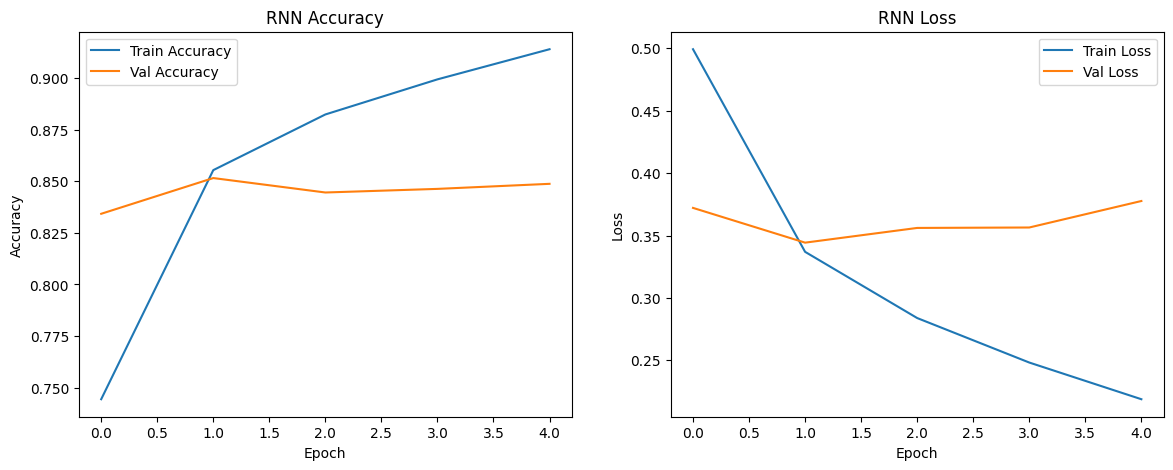

In [16]:
# Get the final test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%\n")

# Plot the training vs validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('RNN Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('RNN Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()